Requisition's Generator

In [1]:
# To activate auto reloading of the modules
%load_ext autoreload

# To reload all modules before executing each cell
%autoreload 2

In [1]:
import numpy as np
import time
import random
import matplotlib.pyplot as plt

from req_generator import Uniform, zipf
from cache import LRU, QLRU, LFU, IRM, FairStatic
from monitor import Monitor

np.random.seed(0)
random.seed(0)

Parameters

In [2]:
f = 10000
t = 10000000
alpha = 0.8
c = int (f * 0.01)
initial_state = list(random.sample(range(f), c))
q = 0.001

In [3]:
num_servers = 2

# def get_server(file_id, total_files, total_servers):

#     server_size = total_files // total_servers

#     server_id = file_id // server_size  

#     return min(server_id, total_servers - 1)


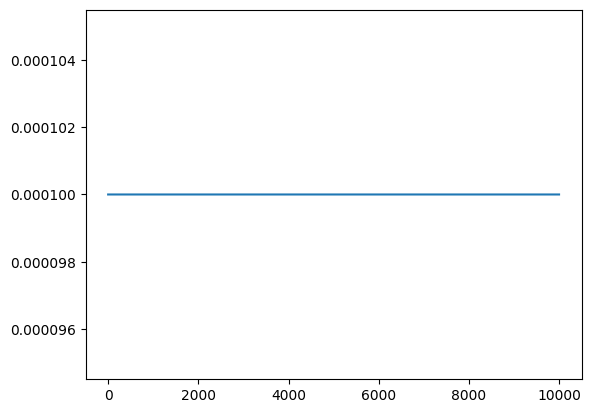

In [4]:
popularities = Uniform(f)
req = np.random.choice(f,t,p=popularities)

plt.plot([i for i in range(f)], popularities)

plt.show()

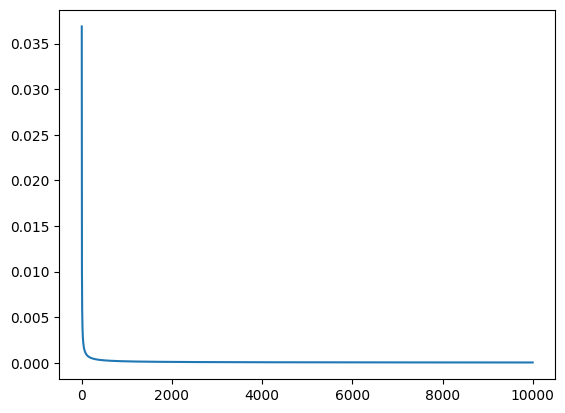

In [5]:
popularities = zipf(alpha, f)
req = np.random.choice(f, t, p=popularities)

plt.plot([i for i in range(f)], popularities)

plt.show()

In [6]:
print(popularities)
print(sum(popularities[:c]))

[3.68858810e-02 2.11853754e-02 1.53166277e-02 ... 2.32771420e-05
 2.32752796e-05 2.32734176e-05]
0.30004585443466814


CACHE

LRU

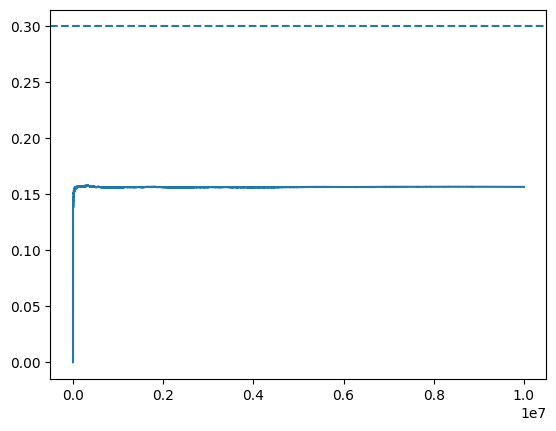

LRU's Hit Rate: 15.67%
Omega: [6306299. 2126907.]
Jain's Fairness Index: 0.8028
Angle of Vector Ω: 18.64 degrees


In [7]:
monitor = Monitor(num_servers, f)

lru = LRU(initial_state, c)
monitor.plot_hit_rate(lru, req, popularities, c, "LRU")


QLRU

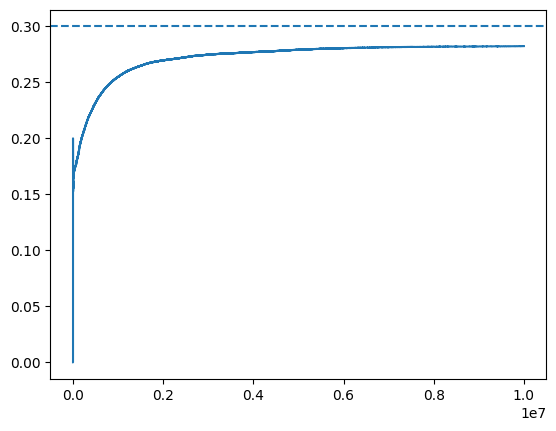

qLRU's Hit Rate: 28.24%
Omega: [5036631. 2139529.]
Jain's Fairness Index: 0.8599
Angle of Vector Ω: 23.02 degrees


In [8]:
qlru = QLRU(initial_state, c, q)
monitor.plot_hit_rate(qlru, req, popularities, c, "qLRU")

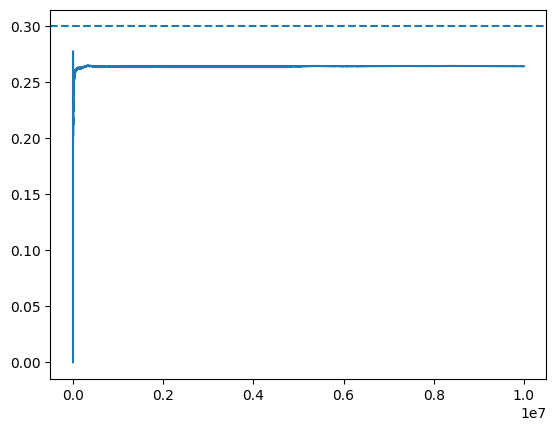

LFU's Hit Rate: 26.45%
Omega: [5216311. 2138964.]
Jain's Fairness Index: 0.8510
Angle of Vector Ω: 22.30 degrees


In [9]:
lfu = LFU(initial_state, c, f)
monitor.plot_hit_rate(lfu, req, popularities, c, "LFU")

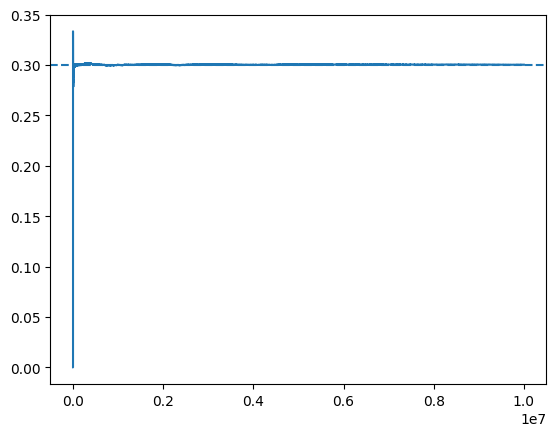

Static IRM's Hit Rate: 30.02%
Omega: [4856447. 2141467.]
Jain's Fairness Index: 0.8692
Angle of Vector Ω: 23.80 degrees


In [10]:
irm_static = IRM(c, popularities)
monitor.plot_hit_rate(irm_static, req, popularities, c, "Static IRM")

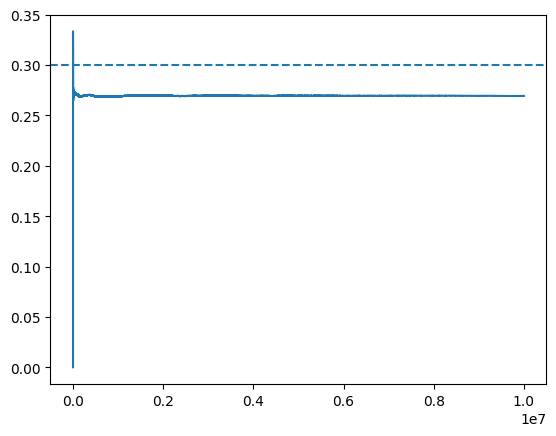

Fair Static's Hit Rate: 26.92%
Omega: [5168844. 2139081.]
Jain's Fairness Index: 0.8533
Angle of Vector Ω: 22.48 degrees


In [11]:
fair_static = FairStatic(c, popularities, num_servers, monitor.file_to_server)
monitor.plot_hit_rate(fair_static, req, popularities, c, "Fair Static")